In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data and initial split


In [ ]:
csv_filename = "uae_real_estate_cleaned.csv"
df = pd.read_csv(csv_filename)

In [ ]:
target_column = "price" #column to be predicted
X = df.drop(columns=[target_column])
y = df[target_column]

# Split into Group 1 (80% Train/Val) and Group 2 (20% Final Holdout Test)
X_group1, X_group2, y_group1, y_group2 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Data loaded successfully!")
print(f"Group 1 (Train/Validation) Size: {X_group1.shape[0]} rows")
print(f"Group 2 (Final Test) Size: {X_group2.shape[0]} rows\n")

Data loaded successfully!
Group 1 (Train/Validation) Size: 3367 rows
Group 2 (Final Test) Size: 842 rows



# 2. K-fold cross validation



In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#baseline models
models = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

print("--- Running K-Fold Cross Validation on Group 1 ---")

cv_results = {}
best_cv_score = float('-inf')
best_model_name = ""

for name, model in models.items():
    # Gather R² scores for all 5 folds
    scores = cross_val_score(model, X_group1, y_group1, cv=kf, scoring='r2')
    mean_score = np.mean(scores)
    cv_results[name] = mean_score
    print(f" {name} -> Average R² Score: {mean_score:.4f}")

    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_model_name = name

print(f"\n Best Model on Practice Data: {best_model_name}\n")

--- Running K-Fold Cross Validation on Group 1 ---
 Ridge Regression -> Average R² Score: 0.4341
 Random Forest -> Average R² Score: 0.5435
 HistGradientBoosting -> Average R² Score: 0.5637

 Best Model on Practice Data: HistGradientBoosting



# 3. Calculating true error on group 2


In [ ]:
# Re-initialize the winning model architecture
if "Ridge" in best_model_name:
    final_model = Ridge()
elif "Random Forest" in best_model_name:
    final_model = RandomForestRegressor(random_state=42)
else:
    final_model = HistGradientBoostingRegressor(random_state=42)

# Train the final model on ALL of Group 1
final_model.fit(X_group1, y_group1)

# Test on the locked-away Group 2
final_predictions = final_model.predict(X_group2)

# Calculate final metrics for your report
true_r2 = r2_score(y_group2, final_predictions)
true_rmse = np.sqrt(mean_squared_error(y_group2, final_predictions))

print(f" Final Model Performance Report:")
print(f"   - Selected Model: {best_model_name}")
print(f"   - True R² Score (Group 2): {true_r2:.4f}")
print(f"   - True Error (RMSE on Group 2): {true_rmse:.2f}\n")

 Final Model Performance Report:
   - Selected Model: HistGradientBoosting
   - True R² Score (Group 2): 0.5461
   - True Error (RMSE on Group 2): 1119576.41



# 4. Plotting resutls

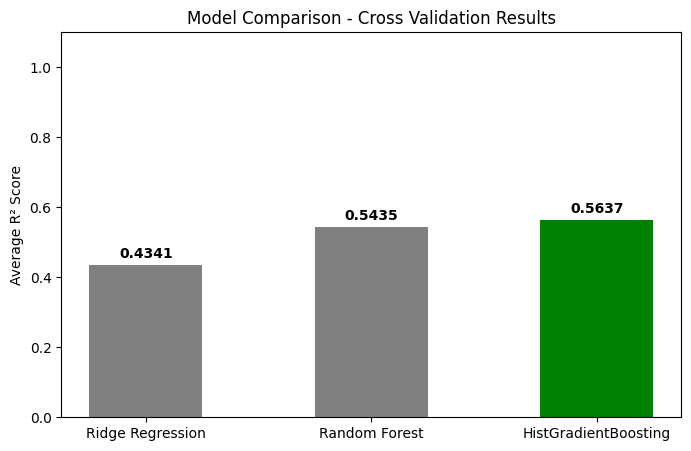

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['gray' if name != best_model_name else 'green' for name in cv_results.keys()]
plt.bar(cv_results.keys(), cv_results.values(), color=colors, width=0.5)
plt.ylabel('Average R² Score')
plt.title('Model Comparison - Cross Validation Results')
plt.ylim(0, 1.1)

# Add data labels on top of the bars
for i, val in enumerate(cv_results.values()):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', fontweight='bold')

plt.show()